# Week 2 hands-on: language models from counts to neural networks

*Generative AI from First Principles* · [course page](https://mathrulestheworld.github.io/genai-first-principles/)

This notebook follows the lecture. Each part is a stop in the talk: the slides give the idea, this notebook shows it working on real text.

| Part | What happens | Lecture notes |
|---|---|---|
| 1. Counting | A bigram model of four sentences, by hand; Shannon's experiment on TinyStories | §§1–2 |
| 2. Smoothing and evaluation | Sparsity, perplexity, smoothing, honest validation and test splits | §§2–4 |
| 3. Word vectors from counts | Co-occurrence counts, PMI, and an SVD | §5 |
| 4. word2vec | Skip-gram with negative sampling, trained live; the vectors in 2-D and 3-D; nearest-neighbor search; why it agrees with counting | §5 |
| 5. Neural language models | The bigram model as a network; word vectors; the model of Bengio et al. (2003): build it, train it, look inside | §6 |
| 6. Take home: recurrent networks | Character-level RNN and LSTM: reading, sampling, temperature, a quotation cell; a word-level LSTM | §§7–8 |

**Data.** [TinyStories](https://arxiv.org/abs/2305.07759) (Eldan and Li, 2023): short stories in simple English. We use its validation file (about 22,000 stories, 19 MB; downloaded on first run into `data/`) and split it by story into 80% training, 10% validation, and 10% test, with a fixed seed, so the numbers match the lecture notes.

**Code.** Everything used here is in the repository: [`tinylm/ngram.py`](../tinylm/ngram.py) (count models and the evaluation harness), [`tinylm/embeddings.py`](../tinylm/embeddings.py) (count vectors and word2vec), [`tinylm/neural.py`](../tinylm/neural.py) (the neural models), and [`tinylm/data.py`](../tinylm/data.py). From this week on we use PyTorch for tensors and gradients; it does what the Week 1 engine does, faster.

**Time.** With `QUICK = True` every cell runs in under a minute on a laptop (the evaluations use 500 stories instead of all of them, so a few numbers differ slightly from the notes). Trained neural models are loaded from `checkpoints/`; each training cell says how to retrain from scratch.

In [1]:
import sys, time, math, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT))                 # use the repository's tinylm without installing it

import numpy as np
import torch
import matplotlib.pyplot as plt

from tinylm.data import tinystories_words, clean_chars, END, UNK
from tinylm import ngram, embeddings, neural

QUICK = False                                 # True: evaluate on 500 stories (faster; numbers differ slightly from the notes)
torch.set_num_threads(max(1, torch.get_num_threads()))
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

data = tinystories_words(ROOT / "data")       # downloads TinyStories-valid.txt on the first run
train, val, test, vocab = data["train"], data["val"], data["test"], data["vocab"]
if QUICK:
    val, test = val[:500], test[:500]
print(f"{len(train):,} training, {len(val):,} validation, {len(test):,} test stories")
print(f"{sum(len(s) + 1 for s in train):,} training tokens (with one END per story); vocabulary of {len(vocab):,} words")
print("first training story:", " ".join(train[0][:40]), "...")

17,592 training, 2,199 validation, 2,199 test stories
3,559,907 training tokens (with one END per story); vocabulary of 8,681 words
first training story: once upon a time , there was a boy named timmy . he loved to sail on his toy boat in the bathtub . one day , he asked his mom if he could sail his boat in the big ...


# Part 1: Counting

## 1.1 A bigram model of four sentences

A **bigram model** predicts each word from the one before it. Its maximum-likelihood estimate is a table of relative frequencies,
$$q(w \mid h) = \frac{c(h, w)}{c(h)},$$
where $c(h, w)$ counts how often $w$ follows $h$. Every sentence starts with the context BOS and ends by predicting END, so the probability of a complete sentence includes the probability of stopping.

*In class:* before running the next cell, guess the word after *the*.

In [2]:
corpus = [s.split() for s in ["the cat sleeps", "the cat eats", "the dog sleeps", "a dog eats"]]
toy_vocab = ["the", "a", "cat", "dog", "sleeps", "eats", END]
bigram = ngram.NGramModel(corpus, 2, toy_vocab)        # alpha = 0: maximum likelihood

print(f"{'history':>9s} " + " ".join(f"{w:>7s}" for w in toy_vocab))
for h in [ngram.BOS, "the", "a", "cat", "dog", "sleeps", "eats"]:
    print(f"{h:>9s} " + " ".join(f"{bigram.prob((h,), w):7.2f}" for w in toy_vocab))

  history     the       a     cat     dog  sleeps    eats    </s>
      <s>    0.75    0.25    0.00    0.00    0.00    0.00    0.00
      the    0.00    0.00    0.67    0.33    0.00    0.00    0.00
        a    0.00    0.00    0.00    1.00    0.00    0.00    0.00
      cat    0.00    0.00    0.00    0.00    0.50    0.50    0.00
      dog    0.00    0.00    0.00    0.00    0.50    0.50    0.00
   sleeps    0.00    0.00    0.00    0.00    0.00    0.00    1.00
     eats    0.00    0.00    0.00    0.00    0.00    0.00    1.00


In [3]:
def sentence_probability(model, sentence):
    p = 1.0
    for history, word in ngram.ngram_events(sentence.split(), model.n):
        p *= model.prob(history, word)
    return p

for s in ["the cat sleeps", "the dog eats", "a cat sleeps"]:
    print(f"q({s}, END) = {sentence_probability(bigram, s):.4f}")

rng = np.random.default_rng(0)
print("\nsamples:", [" ".join(ngram.sample(bigram, rng)) for _ in range(6)])

q(the cat sleeps, END) = 0.2500
q(the dog eats, END) = 0.1250
q(a cat sleeps, END) = 0.0000

samples: ['the cat sleeps', 'a dog eats', 'the dog eats', 'a dog eats', 'a dog sleeps', 'the cat eats']


*the dog eats* never occurred, but each of its transitions did, so it gets probability 1/8. *a cat sleeps* is a fine sentence, but *a cat* never occurred, so it gets probability **zero**. A table of counts can recombine pieces it has seen; it can say nothing about a piece it has not.

## 1.2 Shannon's experiment, repeated

In 1948 Shannon generated text from approximations to English that used more and more context. Here are character models of TinyStories that choose each character from the previous $n-1$, with probabilities equal to relative frequencies in 6,000 training stories, and then word models.

In [4]:
char_train = [clean_chars(s) for s in data["stories"][0][:6000]]
char_test = [clean_chars(s) for s in data["stories"][2][:500]]
alphabet = sorted(set("".join(char_train))) + [END]
print(f"{len(alphabet) - 1} characters: {''.join(alphabet[:-1])!r}\n")

rng = np.random.default_rng(3)
for n in [1, 2, 3, 5, 7]:
    model = ngram.NGramModel(char_train, n, alphabet)
    print(f"n={n}: " + "".join(ngram.sample(model, rng, max_tokens=110)))

33 characters: ' !"\',.?abcdefghijklmnopqrstuvwxyz'



n=1:  ari ef o eheiowamna wactifp oe nu,laoo.smnseot sef nataiel! ooit,s wllwrr d  .t agswo.hn ndinnhi"g ghpe h,oee


n=2: omame oventotouge foked jir bimilay be d w, sty no pasth anoele s heded junt hend. sed. shed nopomas tow. the,


n=3: once. the fried to pup. theling, chim aps carelf. tored clow she trienth excithe day st, he it way saing. jobo


n=5: once upon a time, they are so to learned by even they hated to be one day that how flourful all the came in. i


n=7: once upon a time, there was a hairy dust an original book store to carrying, he heard some bugs and waved goin


In [5]:
rng = np.random.default_rng(11)
for n in [1, 2, 3]:
    model = ngram.NGramModel(train, n, vocab)
    print(f"n={n}: " + neural.detokenize(ngram.sample(model, rng, max_tokens=30, exclude=(UNK,))))

n=1: . is no,. wanted.. was on finally it quieter big. the return it the little with and living i enjoy my and the to.


n=2: once upon a time, " she gave them. " he jumped into the pretty and across a young dove there. " timmy loved the firework, a


n=3: ben liked to eat some bread, cheese and ate their delicious desserts and laughed as the sun. it is white and had fun. then, a kind


# Part 2: Smoothing and evaluation

## 2.1 Sparsity

How many n-grams of new text were never seen in training? Good–Turing's estimate of the probability that the next n-gram is new is $N_1/N$, the fraction of training occurrences that belong to n-grams seen exactly once. It can be checked against the test stories.

In [6]:
for n in [2, 3, 4]:
    observed = ngram.unseen_fraction(train, test, n)
    line = f"{n}-grams: {100 * observed:5.1f}% of test n-grams never occur in training"
    if n < 4:
        line += f"   (Good-Turing predicts {100 * ngram.good_turing_unseen(train, n):.1f}%)"
    print(line)

2-grams:   3.8% of test n-grams never occur in training   (Good-Turing predicts 3.5%)


3-grams:  18.3% of test n-grams never occur in training   (Good-Turing predicts 17.9%)


4-grams:  41.1% of test n-grams never occur in training


## 2.2 Smoothing, measured by perplexity

The evaluation harness scores a model by its average log loss on held-out stories, in nats per predicted token (END included), and reports **perplexity** $= e^{\text{loss}}$: a model that spreads probability uniformly over $K$ tokens has perplexity $K$. Lower is better.

- **Add-$\alpha$**: $q(w\mid h) = (c(h,w)+\alpha)/(c(h)+\alpha|V|)$, with $\alpha$ chosen on the validation stories.
- **Interpolated Kneser–Ney**: discount every count by $D = 0.75$ and give the freed mass to a lower-order model built from *continuation counts* (how many different words a word follows).

In [7]:
start = time.time()
results = {}
for n in [1, 2, 3]:
    best_alpha, best_loss = None, math.inf
    for alpha in [1, 0.1, 0.01, 0.003, 0.001]:
        loss = ngram.log_loss(ngram.NGramModel(train, n, vocab, alpha=alpha), val)
        if loss < best_loss:
            best_alpha, best_loss = alpha, loss
    results[("add-one", n)] = ngram.perplexity(ngram.NGramModel(train, n, vocab, alpha=1), test)
    results[("add-alpha", n)] = ngram.perplexity(ngram.NGramModel(train, n, vocab, alpha=best_alpha), test)
    print(f"n={n}: best alpha on validation = {best_alpha}")
kn = {}
for n in [2, 3, 4]:
    kn[n] = ngram.KneserNeyModel(train, n, vocab)
    results[("Kneser-Ney", n)] = ngram.perplexity(kn[n], test)

print(f"\n{'test perplexity':22s}" + "".join(f"{n:>9d}-gram" for n in [1, 2, 3, 4]))
for name in ["add-one", "add-alpha", "Kneser-Ney"]:
    row = "".join(f"{results[(name, n)]:14.1f}" if (name, n) in results else f"{'':14s}" for n in [1, 2, 3, 4])
    print(f"{name:22s}{row}")
print(f"\n({time.time() - start:.0f} s)")

n=1: best alpha on validation = 0.001


n=2: best alpha on validation = 0.003


n=3: best alpha on validation = 0.001



test perplexity               1-gram        2-gram        3-gram        4-gram
add-one                        300.5         110.5         420.7              
add-alpha                      300.4          51.7          58.6              
Kneser-Ney                                    47.5          27.9          24.6

(103 s)


Add-one smoothing makes the trigram model *worse* than the bigram model: each trigram history is seen only a few times, and 8,681 pseudo-counts swamp the real ones. With the same counts, how probability is shared out decides whether longer context helps.

## 2.3 Choose on validation, report on test

The four-sentence corpus again, now with held-out sentences: validation {*a cat sleeps*, *a cat eats*} and test {*the dog eats*, *a dog sleeps*}. We choose $\alpha$ on validation, then report test once.

In [8]:
toy_val = [s.split() for s in ["a cat sleeps", "a cat eats"]]
toy_test = [s.split() for s in ["the dog eats", "a dog sleeps"]]
print(f"{'alpha':>6s} {'validation loss':>16s} {'test loss':>10s}")
for alpha in [0, 0.01, 0.1, 0.5, 1]:
    m = ngram.NGramModel(corpus, 2, toy_vocab, alpha=alpha)
    print(f"{alpha:6} {ngram.log_loss(m, toy_val):16.3f} {ngram.log_loss(m, toy_test):10.3f}")

 alpha  validation loss  test loss
     0              inf      0.520
  0.01            1.703      0.545
   0.1            1.359      0.727
   0.5            1.474      1.139
     1            1.597      1.365


Validation picks $\alpha = 0.1$; its test loss, 0.727 nats per token (perplexity 2.07), is the number to report. Choosing on the test set would have picked $\alpha = 0$, because every transition of the two test sentences happens to occur in training; that model gives the validation sentences probability zero.

## 2.4 How much does more context help?

Character models of increasing order $n$, smoothed with Kneser–Ney: bits per character on the training text and on held-out stories, and the fraction of held-out characters whose $n$-gram was never seen in training (to which an unsmoothed model assigns probability zero). The loss on the training text keeps falling; the held-out loss improves more and more slowly, and the gap between the two is overfitting. This cell takes about six minutes (with `QUICK = True`, two); in class, show Figure 1 of the notes.

n=1: training 4.220, held-out 4.217 bits per character; 0.0% of held-out 1-grams unseen   (3 s)


n=2: training 3.262, held-out 3.258 bits per character; 0.0% of held-out 2-grams unseen   (8 s)


n=3: training 2.464, held-out 2.468 bits per character; 0.0% of held-out 3-grams unseen   (16 s)


n=4: training 1.876, held-out 1.889 bits per character; 0.2% of held-out 4-grams unseen   (27 s)


n=5: training 1.559, held-out 1.591 bits per character; 0.7% of held-out 5-grams unseen   (42 s)


...

n=7: training 1.203, held-out 1.342 bits per character; 4.9% of held-out 7-grams unseen   (93 s)


n=8: training 1.077, held-out 1.296 bits per character; 8.8% of held-out 8-grams unseen   (129 s)


n=9: training 0.957, held-out 1.273 bits per character; 13.9% of held-out 9-grams unseen   (174 s)


n=10: training 0.844, held-out 1.264 bits per character; 20.1% of held-out 10-grams unseen   (230 s)


n=11: training 0.740, held-out 1.266 bits per character; 26.9% of held-out 11-grams unseen   (300 s)


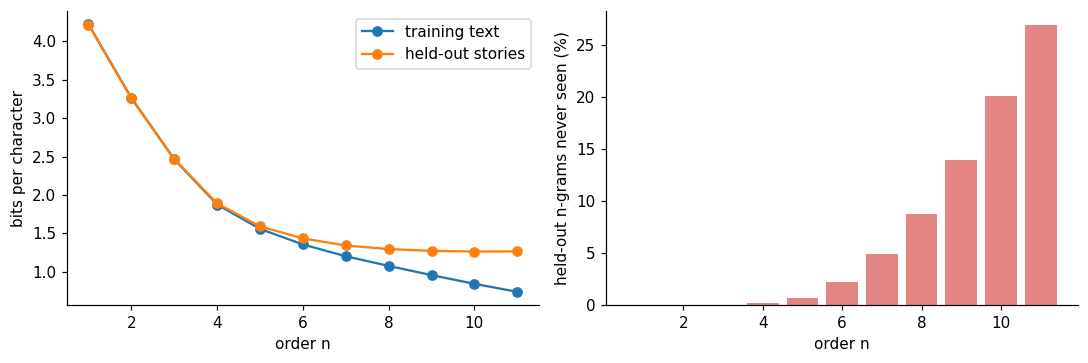

In [9]:
start = time.time()
orders = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] if not QUICK else [1, 3, 5, 7, 9]
held_out = char_test if not QUICK else char_test[:200]
train_part = char_train[:300]
rows = []
for n in orders:
    model = ngram.NGramModel(char_train, 1, alphabet) if n == 1 else ngram.KneserNeyModel(char_train, n, alphabet)
    rows.append((n, ngram.bits_per_token(model, train_part), ngram.bits_per_token(model, held_out),
                 ngram.unseen_fraction(char_train, held_out, n)))
    print(f"n={n}: training {rows[-1][1]:.3f}, held-out {rows[-1][2]:.3f} bits per character; "
          f"{100 * rows[-1][3]:.1f}% of held-out {n}-grams unseen   ({time.time() - start:.0f} s)")
best_char_ngram = min(r[2] for r in rows)

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4))
a.plot([r[0] for r in rows], [r[1] for r in rows], "o-", label="training text")
a.plot([r[0] for r in rows], [r[2] for r in rows], "o-", label="held-out stories")
a.set_xlabel("order n"); a.set_ylabel("bits per character"); a.legend()
b.bar([r[0] for r in rows], [100 * r[3] for r in rows], color="#D1342F", alpha=0.6)
b.set_xlabel("order n"); b.set_ylabel("held-out n-grams never seen (%)")
plt.tight_layout(); plt.show()

# Part 3: Word vectors from counts

A word as an index (a one-hot vector) is equally far from every other word. We want vectors in which words used alike are near each other. The first route counts: how often does each word occur within two positions of each other word? **Pointwise mutual information** compares a co-occurrence count with what independence would predict,
$$\mathrm{PMI}(w, c) = \log \frac{p(w, c)}{p(w)\,p(c)}.$$
We keep the positive part (PPMI) and compress the rows with a truncated SVD to 100 numbers per word.

In [10]:
start = time.time()
text = embeddings.content_words(train)                          # drop punctuation and <unk>
top_words, word_counts = embeddings.frequent_words(text, how_many=3000)
counts = embeddings.cooccurrence_counts(text, top_words, window=2)
P = embeddings.pmi(counts)
ix = {w: i for i, w in enumerate(top_words)}
for a_, b_ in [("ice", "cream"), ("once", "upon"), ("the", "dog"), ("happy", "sad")]:
    print(f"PMI({a_}, {b_}) = {P[ix[a_], ix[b_]]:5.2f}   ({int(counts[ix[a_], ix[b_]]):,} co-occurrences)")
count_vectors = embeddings.svd_vectors(embeddings.ppmi(counts), 100)
print(f"\n{len(top_words)} words x 100 dimensions  ({time.time() - start:.0f} s)\n")
for q in ["mom", "red", "ran", "sad", "apple", "three"]:
    print(f"{q:>6s}: " + ", ".join(w for w, s in embeddings.nearest(count_vectors, top_words, q)))

PMI(ice, cream) =  6.68   (628 co-occurrences)
PMI(once, upon) =  4.99   (10,850 co-occurrences)
PMI(the, dog) =  1.17   (2,596 co-occurrences)
PMI(happy, sad) = -2.18   (11 co-occurrences)



3000 words x 100 dimensions  (17 s)

   mom: dad, mommy, mother, mum, parents
   red: blue, yellow, green, pink, purple
   ran: walked, went, headed, jumped, skipped
   sad: scared, upset, ashamed, embarrassed, lonely
 apple: berry, fruit, melon, cherry, cookie
 three: years, five, four, counted, two


# Part 4: word2vec

The second route predicts. **Skip-gram with negative sampling** gives each word a vector $\mathbf v_w$ and a context vector $\mathbf u_w$, and trains them so that a logistic regression can tell a real (word, neighbor) pair from a made-up one:
$$\text{loss} = -\log\sigma(\mathbf v_w\cdot\mathbf u_c) - \sum_{i=1}^{k}\log\sigma(-\mathbf v_w\cdot\mathbf u_{c'_i}),$$
with $k = 5$ "negative" contexts $c'_i$ drawn at random (unigram frequencies to the power 3/4). The model is 20 lines in [`tinylm/embeddings.py`](../tinylm/embeddings.py). Every word starts with a random vector.

Ten passes over the training stories take about two minutes on a laptop. *In class:* set `PASSES = 3` (about a minute); the clusters already appear, while the analogies below need the full ten.

In [11]:
PASSES = 10
w2v_words, _ = embeddings.frequent_words(text, min_count=5)
print(f"{len(w2v_words):,} words occur at least five times")
start = time.time()
w2v, w2v_info = embeddings.train_skipgram(text, w2v_words, word_counts, dim=100, passes=PASSES)
print(f"({time.time() - start:.0f} s)")
w2v_vectors = w2v.v.weight.detach().numpy()
for q in ["happy", "sad", "dog", "king", "apple", "park"]:
    print(f"{q:>6s}: " + ", ".join(w for w, s in embeddings.nearest(w2v_vectors, w2v_words, q)))

6,453 words occur at least five times


pass 1: 2,706,481 pairs, average loss 2.773


pass 2: 2,708,194 pairs, average loss 2.536


pass 3: 2,706,210 pairs, average loss 2.414


pass 4: 2,708,225 pairs, average loss 2.358


...

pass 6: 2,710,272 pairs, average loss 2.303


pass 7: 2,708,181 pairs, average loss 2.287


pass 8: 2,708,474 pairs, average loss 2.278


pass 9: 2,709,419 pairs, average loss 2.270


pass 10: 2,709,970 pairs, average loss 2.265
(159 s)
 happy: grateful, thankful, thanked, glad, pleased
   sad: upset, unhappy, heartbroken, ashamed, miserable
   dog: rex, barking, barks, barked, dog's
  king: queen, prince, kingdom, princess, knight
 apple: fruit, juicy, apples, peach, berry
  park: swings, playground, walk, lawn, seesaw


## Before and after, in two dimensions

Six groups of words, projected to two dimensions with t-SNE (which keeps near neighbors near; distances between clusters mean little). Nothing in the objective names a group.

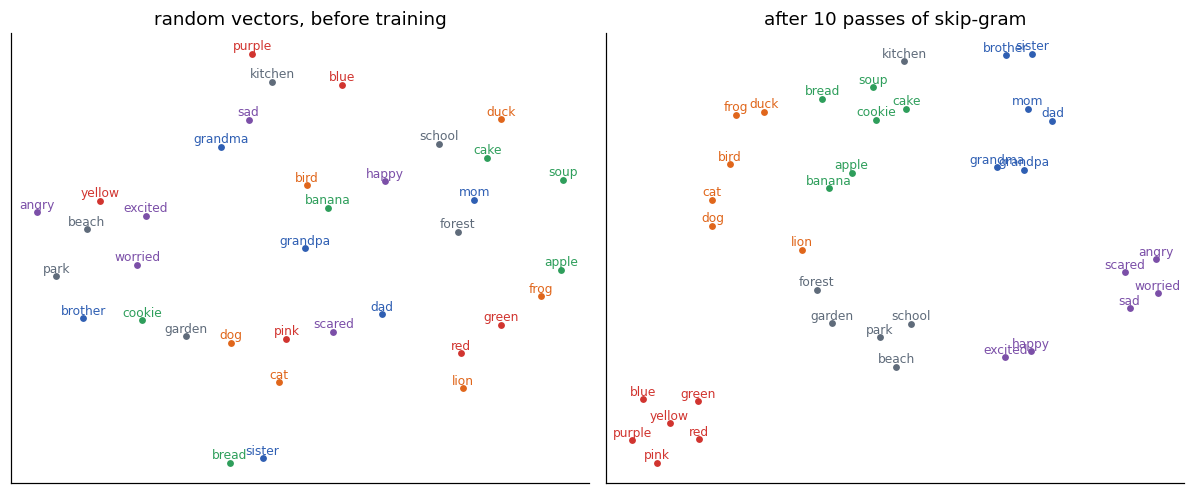

In [12]:
from sklearn.manifold import TSNE

GROUPS = {"colors": ["red", "blue", "green", "yellow", "pink", "purple"],
          "animals": ["dog", "cat", "bird", "frog", "lion", "duck"],
          "family": ["mom", "dad", "sister", "brother", "grandma", "grandpa"],
          "feelings": ["happy", "sad", "scared", "angry", "excited", "worried"],
          "food": ["apple", "cake", "cookie", "banana", "soup", "bread"],
          "places": ["park", "school", "garden", "forest", "beach", "kitchen"]}
COLORS = {"colors": "#D1342F", "animals": "#E0661B", "family": "#2F5FB3",
          "feelings": "#7B4FA8", "food": "#2E9E5B", "places": "#5F6B7A"}

def project(vectors, dims=2, seed=0):
    unit = embeddings.unit_rows(vectors)
    return TSNE(n_components=dims, perplexity=6, metric="cosine", init="pca", random_state=seed).fit_transform(unit)

def plot_groups(ax, vectors, words, title):
    chosen = [(w, g) for g, ws in GROUPS.items() for w in ws]
    xy = project(np.array([vectors[words.index(w)] for w, g in chosen]))
    for (w, g), (x, y) in zip(chosen, xy):
        ax.scatter(x, y, color=COLORS[g], s=12)
        ax.annotate(w, (x, y), fontsize=8, color=COLORS[g], xytext=(0, 3), textcoords="offset points", ha="center")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_groups(axes[0], w2v_info["before"], w2v_words, "random vectors, before training")
plot_groups(axes[1], w2v_vectors, w2v_words, f"after {PASSES} passes of skip-gram")
plt.tight_layout(); plt.show()

## In three dimensions

The same idea with more words, projected to three dimensions. Drag to rotate (in Jupyter or VS Code; the static copy on GitHub does not show interactive plots). Needs `pip install plotly`.

In [13]:
try:
    import plotly.graph_objects as go
    MORE = {"colors": ["orange", "white", "black", "brown", "gray", "gold"],
            "animals": ["bunny", "bear", "fish", "puppy", "kitten", "horse", "cow", "pig", "monkey"],
            "family": ["mommy", "daddy", "mother", "father", "baby", "aunt", "uncle"],
            "feelings": ["proud", "upset", "lonely", "surprised", "curious", "nervous"],
            "food": ["pie", "candy", "milk", "juice", "pizza", "carrot", "sandwich"],
            "places": ["house", "store", "beach", "zoo", "farm", "river", "castle"]}
    chosen = [(w, g) for g in GROUPS for w in GROUPS[g] + MORE[g] if w in w2v_words]
    chosen = list(dict.fromkeys(chosen))
    xyz = project(np.array([w2v_vectors[w2v_words.index(w)] for w, g in chosen]), dims=3)
    fig3d = go.Figure()
    for g in GROUPS:
        pts = [(p, w) for p, (w, gg) in zip(xyz, chosen) if gg == g]
        fig3d.add_trace(go.Scatter3d(x=[p[0] for p, w in pts], y=[p[1] for p, w in pts], z=[p[2] for p, w in pts],
                                     mode="markers+text", text=[w for p, w in pts], name=g,
                                     marker=dict(size=4, color=COLORS[g]), textfont=dict(size=10, color=COLORS[g])))
    fig3d.update_layout(height=600, margin=dict(l=0, r=0, t=0, b=0))
    fig3d.show()
except ImportError:
    print("plotly is not installed: pip install plotly")

## Analogies

If relations are consistent directions, then $\mathbf v_{\text{girl}} - \mathbf v_{\text{boy}} + \mathbf v_{\text{he}}$ should land near $\mathbf v_{\text{she}}$. On a corpus this small some analogies work and some do not.

In [14]:
for a_, b_, c_ in [("boy", "girl", "he"), ("he", "she", "his"), ("mom", "dad", "mommy"), ("run", "ran", "walk"),
                   ("boy", "girl", "brother"), ("king", "queen", "prince"), ("one", "two", "three")]:
    print(f"{a_} : {b_} :: {c_} : ?   " + ", ".join(f"{w} ({s})" for w, s in embeddings.analogy(w2v_vectors, w2v_words, a_, b_, c_)))

boy : girl :: he : ?   she (0.85), her (0.59), molly (0.59)
he : she :: his : ?   her (0.93), lily's (0.73), sally's (0.62)
mom : dad :: mommy : ?   daddy (0.85), mum (0.67), jennifer (0.65)
run : ran :: walk : ?   walked (0.74), winding (0.64), wandered (0.63)
boy : girl :: brother : ?   sister (0.56), mandy's (0.56), her (0.54)
king : queen :: prince : ?   servant (0.68), prince's (0.68), kingdom (0.67)
one : two :: three : ?   girls (0.57), five (0.55), four (0.55)


## A tiny vector database

Search engines, recommendation systems, and assistants that look up documents all store items as vectors and ask one question: *which stored vectors are nearest to this one?* Exact search compares the query with every stored vector, $O(Nd)$ work per query. Fine for our 6,000 words; slow for a billion items, which is why vector databases use approximate methods (hashing, quantization, graphs of neighbors).

In [15]:
E = embeddings.unit_rows(w2v_vectors)
query = E[w2v_words.index("cake")]
start = time.time()
best = embeddings.top_k(E, query, 6)
print(f"nearest to 'cake' among {len(E):,} vectors: {[w2v_words[i] for i in best]}  ({1000 * (time.time() - start):.1f} ms)")

big = np.random.default_rng(0).standard_normal((1_000_000, 100)).astype(np.float32)
start = time.time()
embeddings.top_k(big, big[0], 5)
print(f"one exact query over 1,000,000 random vectors: {1000 * (time.time() - start):.0f} ms")
del big

nearest to 'cake' among 6,453 vectors: ['cake', 'pizza', 'cookies', 'oven', 'baked', 'frosting']  (0.4 ms)


one exact query over 1,000,000 random vectors: 70 ms


## Counting and prediction meet

Levy and Goldberg (2014): if every pair could be fitted freely, skip-gram's optimum is
$$\mathbf v_w\cdot\mathbf u_c = \log\frac{n(w,c)}{k\,n(w)\,p_n(c)} \;\approx\; \mathrm{PMI}(w,c) - \log k,$$
a shifted PMI, computed from the pair counts. Check it on the pairs of the last training pass.

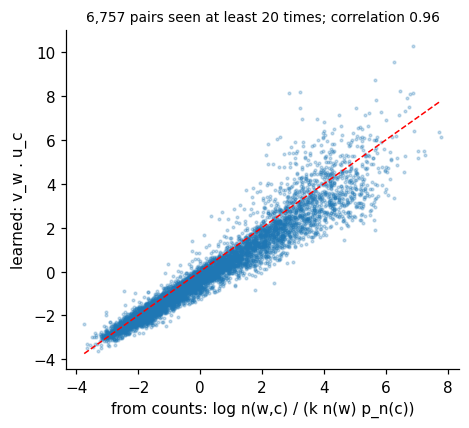

In [16]:
predicted, learned = embeddings.shifted_pmi_check(w2v, w2v_info, min_count=20)
r = np.corrcoef(predicted, learned)[0, 1]
plt.figure(figsize=(4.6, 4))
plt.scatter(predicted, learned, s=3, alpha=0.25)
lo, hi = predicted.min(), predicted.max()
plt.plot([lo, hi], [lo, hi], "r--", lw=1)
plt.xlabel("from counts: log n(w,c) / (k n(w) p_n(c))"); plt.ylabel("learned: v_w . u_c")
plt.title(f"{len(predicted):,} pairs seen at least 20 times; correlation {r:.2f}", fontsize=9)
plt.show()

# Part 5: Neural language models

Three steps, as in the lecture notes (§6) and Karpathy's [makemore](https://www.youtube.com/watch?v=PaCmpygFfXo) lectures: the bigram model computed by a network, the same network with its matrix factored through word vectors, and the fixed-window model of Bengio et al. (2003).

## 5.1 The bigram model as a network

A one-hot vector times a weight matrix $W$ picks out a row of $W$; the softmax turns the row into probabilities. Trained by gradient descent on the log loss, the rows must converge to the relative frequencies of §2: maximum likelihood is the same whether computed by counting or by descent. Characters keep the matrix small ($34 \times 34$).

counting:    training 3.262   held-out 3.258 bits per character
the network: training 3.262   held-out 3.258 bits per character   (5 s; uniform would be 5.09)


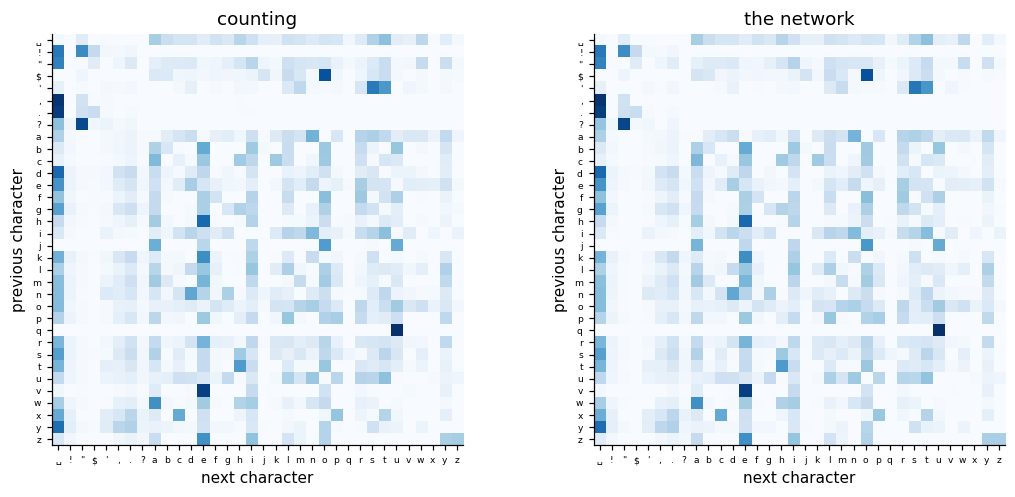

In [17]:
char_alpha = neural.char_alphabet(char_train)
end_id = char_alpha.index(neural.STORY_END)
pairs_train = torch.cat([torch.tensor([end_id]), neural.encode_chars(char_train, char_alpha)])
pairs_test = torch.cat([torch.tensor([end_id]), neural.encode_chars(char_test, char_alpha)])
a_tr, b_tr, a_te, b_te = pairs_train[:-1], pairs_train[1:], pairs_test[:-1], pairs_test[1:]
K = len(char_alpha)

# counting
N = torch.zeros(K, K)
N.index_put_((a_tr, b_tr), torch.ones(len(a_tr)), accumulate=True)
P_count = (N + 0.01) / (N.sum(1, keepdim=True) + 0.01 * K)        # a little add-alpha for the 4 unseen held-out pairs
bits = lambda P, a, b: float(-torch.log2(P[a, b]).mean())

# the network, trained by minibatch gradient descent
torch.manual_seed(0)
net = neural.BigramNet(K, K)
opt = torch.optim.Adam(net.parameters(), lr=0.1)
start = time.time()
for step in range(1, 3001):
    i = torch.randint(0, len(a_tr), (4096,))
    loss = torch.nn.functional.cross_entropy(net(a_tr[i]), b_tr[i])
    opt.zero_grad(); loss.backward(); opt.step()
    if step == 2100:
        for g in opt.param_groups: g["lr"] = 0.01
P_net = torch.softmax(net.W.weight.detach(), 1)
print(f"counting:    training {bits(P_count, a_tr, b_tr):.3f}   held-out {bits(P_count, a_te, b_te):.3f} bits per character")
print(f"the network: training {bits(P_net, a_tr, b_tr):.3f}   held-out {bits(P_net, a_te, b_te):.3f} bits per character"
      f"   ({time.time() - start:.0f} s; uniform would be {math.log2(K):.2f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, P, title in [(axes[0], P_count, "counting"), (axes[1], P_net, "the network")]:
    ax.imshow(P ** 0.5, cmap="Blues")
    ax.set_xticks(range(K)); ax.set_xticklabels(["␣" if c == " " else c for c in char_alpha], fontsize=6)
    ax.set_yticks(range(K)); ax.set_yticklabels(["␣" if c == " " else c for c in char_alpha], fontsize=6)
    ax.set_title(title); ax.set_xlabel("next character"); ax.set_ylabel("previous character")
plt.tight_layout(); plt.show()

## 5.2 From a table to word vectors

For words the same matrix would be $8{,}682 \times 8{,}681$, 75 million numbers, each row learned only from its own word. Factor it: $q(\cdot\mid v) = \operatorname{softmax}(\mathbf b + U\,C(v))$ with a 64-dimensional vector $C(v)$ per word. Similar words must now share. The notes train it for two passes (about 14,000 steps, 13 minutes on a laptop) to a test perplexity of 49.9; here a shorter run.

In [18]:
BIGRAM_STEPS = 3000 if QUICK else 4000                  # 14,000 for the notes' two passes
index = neural.word_index(vocab)
X1, Y1 = neural.make_windows(train, index, context=1)
X1_val, Y1_val = neural.make_windows(val, index, context=1)
torch.manual_seed(0)
fb = neural.BigramNet(len(vocab) + 1, len(vocab), embed_dim=64)
print(f"{sum(p.numel() for p in fb.parameters()):,} parameters, against {(len(vocab) + 1) * len(vocab):,} for the full matrix")
start = time.time()
neural.train_window_lm(fb, X1, Y1, X1_val[:50000], Y1_val[:50000], epochs=2, eval_every=1000, max_steps=BIGRAM_STEPS)
print(f"({time.time() - start:.0f} s)   Kneser-Ney bigram: {results[('Kneser-Ney', 2)]:.1f}")

1,119,913 parameters, against 75,368,442 for the full matrix


step   1000   validation perplexity   81.89   (50 s)


step   2000   validation perplexity   65.64   (110 s)


step   3000   validation perplexity   60.61   (167 s)


step   4000   validation perplexity   58.10   (227 s)


(229 s)   Kneser-Ney bigram: 47.5


## 5.3 The fixed-window model

Bengio, Ducharme, Vincent, and Jauvin (2003) predicted the next word from the previous four through learned word vectors:
$$q(\cdot \mid x_{t-4:t-1}) = \operatorname{softmax}\big(\mathbf b + U \tanh(\mathbf d + H[C(x_{t-4}); \dots; C(x_{t-1})])\big).$$
$C$ is a table of word vectors, learned together with everything else by minimizing the cross-entropy of the next word. Here is the whole model:

In [19]:
import inspect
print(inspect.getsource(neural.FixedWindowLM))

X_train, Y_train = neural.make_windows(train, index, context=4)
X_val, Y_val = neural.make_windows(val, index, context=4)
X_test, Y_test = neural.make_windows(test, index, context=4)
print(f"{len(X_train):,} training examples: (four previous words, next word)")

class FixedWindowLM(nn.Module):
    """q(next word | previous `context` words) = softmax(b + U tanh(d + H [C(x_1); ...; C(x_k)])).

    C is the word table: one learned vector of size embed_dim per input symbol (the vocabulary
    plus BOS). The vectors of the context words are concatenated, passed through one tanh layer
    (H, d) and turned into scores for every word of the vocabulary (U, b).
    """

    def __init__(self, n_inputs, vocab_size, context=4, embed_dim=64, hidden=128):
        super().__init__()
        self.context = context
        self.C = nn.Embedding(n_inputs, embed_dim)
        self.H = nn.Linear(context * embed_dim, hidden)
        self.U = nn.Linear(hidden, vocab_size)

    def forward(self, x):
        """x: (batch, context) word ids. Returns (batch, vocab_size) scores (logits)."""
        e = self.C(x).flatten(1)                 # (batch, context * embed_dim): the vectors side by side
        h = torch.tanh(self.H(e))                # (batch, hidden)
        r

3,559,907 training examples: (four previous words, next word)


## Watch it learn

The training loop: take a random minibatch of 512 examples, compute the cross-entropy, backpropagate, take an Adam step. A few hundred steps already beat the add-one models of Part 2. Training fully (two passes, about ten minutes on a laptop) gives the checkpoint loaded below; set `TRAIN_FULL = True` to retrain it yourself.

In [20]:
TRAIN_FULL = False
torch.manual_seed(0)
fresh = neural.FixedWindowLM(len(vocab) + 1, len(vocab), context=4, embed_dim=64, hidden=128)
print(f"{sum(p.numel() for p in fresh.parameters()):,} parameters")
start = time.time()
if TRAIN_FULL:
    neural.train_window_lm(fresh, X_train, Y_train, X_val, Y_val, epochs=2)
    torch.save(fresh.state_dict(), ROOT / "checkpoints" / "week02_fixed_window.pt")
else:
    neural.train_window_lm(fresh, X_train, Y_train, X_val[:50000], Y_val[:50000], epochs=1, eval_every=100, max_steps=500)
print(f"({time.time() - start:.0f} s)")

lm = neural.FixedWindowLM(len(vocab) + 1, len(vocab), context=4, embed_dim=64, hidden=128)
lm.load_state_dict(torch.load(ROOT / "checkpoints" / "week02_fixed_window.pt"))
print(f"\ntrained model (checkpoint): test perplexity {math.exp(neural.average_loss(lm, X_test, Y_test)):.1f}"
      f"   (Kneser-Ney 4-gram: {results[('Kneser-Ney', 4)]:.1f})")

1,708,393 parameters


step    100   validation perplexity  155.45   (7 s)


step    200   validation perplexity  102.52   (13 s)


step    300   validation perplexity   83.00   (21 s)


step    400   validation perplexity   72.61   (29 s)


step    500   validation perplexity   65.13   (37 s)


(39 s)



trained model (checkpoint): test perplexity 26.9   (Kneser-Ney 4-gram: 24.6)


## Neural and count models make different errors

Average the two models' probabilities, $\lambda\,q_{\text{neural}} + (1-\lambda)\,q_{\text{KN}}$, with $\lambda$ chosen on validation. Bengio and colleagues found the same: the mixture beats both.

In [21]:
def token_probabilities(model, X, Y):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), 8192):
            out.append(torch.softmax(model(X[i:i + 8192]), -1).gather(1, Y[i:i + 8192, None])[:, 0])
    return torch.cat(out).numpy()

def kn_probabilities(model, stories):
    return np.array([model.prob(h, w) for s in stories for h, w in ngram.ngram_events(s, model.n)])

start = time.time()
p_nn_val, p_kn_val = token_probabilities(lm, X_val, Y_val), kn_probabilities(kn[4], val)
best = min((-np.log(l * p_nn_val + (1 - l) * p_kn_val).mean(), l) for l in np.linspace(0.05, 0.95, 19))
lam = best[1]
p_nn_test, p_kn_test = token_probabilities(lm, X_test, Y_test), kn_probabilities(kn[4], test)
print(f"test perplexity: neural {np.exp(-np.log(p_nn_test).mean()):.1f}, Kneser-Ney {np.exp(-np.log(p_kn_test).mean()):.1f}, "
      f"mixture with weight {lam:.2f} on the neural model {np.exp(-np.log(lam * p_nn_test + (1 - lam) * p_kn_test).mean()):.1f}"
      f"   ({time.time() - start:.0f} s)")

test perplexity: neural 26.9, Kneser-Ney 24.6, mixture with weight 0.40 on the neural model 21.4   (40 s)


## Look inside

Its next-word distributions, its samples (each probability raised to the power $1/T$ with temperature $T = 0.8$, which sharpens the distribution), and its word table $C$, which was never asked about meaning.

In [22]:
for prompt in ["she was very", "once upon a", "the dog wagged its", "they went to the"]:
    top = neural.next_word_distribution(lm, index, vocab, prompt.split())
    print(f"{prompt + ' ...':22s} " + ", ".join(f"{w} {p:.2f}" for w, p in top))
print()
for seed in [1, 2, 3]:
    print(neural.detokenize(neural.sample_words(lm, index, vocab, temperature=0.8, seed=seed)), "\n")

she was very ...       excited 0.16, happy 0.10, sad 0.06, proud 0.04, curious 0.04
once upon a ...        time 1.00, long 0.00, place 0.00, sunny 0.00, special 0.00
the dog wagged its ... tail 0.96, friends 0.00, neck 0.00, eyes 0.00, tears 0.00
they went to the ...   park 0.23, kitchen 0.12, store 0.06, beach 0.04, airport 0.03

once upon a time, there was a little boy named timmy. timmy loved to play. from that day on, lily thought it was so cool. he looked around and saw a tiny mouse. he was so relieved. it was so heavy! he had to go home. he crossed the store, 

once upon a time, there were two friends, squirrels, and then i will try to learn. he wanted to go home with her. she walked in the station and started to swing, mia can do it! " he said. " hi lily, " lila says. the ostrich is too. 

one day, she went to the park she found a bucket and she was very good. he didn't understand why his mom looked. he saw a big pile of leaves. she made a loud noise. the cat was very busy. he h

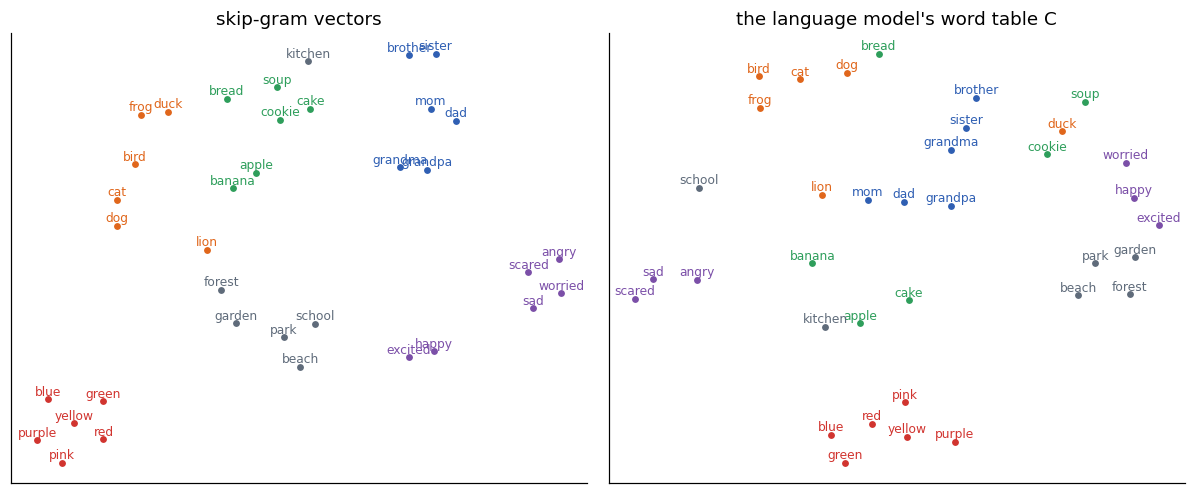

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_groups(axes[0], w2v_vectors, w2v_words, "skip-gram vectors")
plot_groups(axes[1], lm.C.weight.detach().numpy()[:len(vocab)], vocab, "the language model's word table C")
plt.tight_layout(); plt.show()

# Part 6 (take home): recurrent language models

This part follows §§7–8 of the notes and Karpathy's essay [*The Unreasonable Effectiveness of Recurrent Neural Networks*](https://karpathy.github.io/2015/05/21/rnn-effectiveness/). A fixed window forgets everything more than four words back. A recurrent network keeps a state that it updates once per token, $\mathbf h_t = \tanh(W\mathbf h_{t-1} + V\mathbf e_t + \mathbf d)$, with the same weights at every step; the LSTM adds a cell updated *additively*, $\mathbf c_t = \mathbf f_t\odot\mathbf c_{t-1} + \mathbf i_t\odot\mathbf g_t$, so gradients can reach far back. The models are character-level: they read and write one character at a time. They are defined in [`tinylm/neural.py`](../tinylm/neural.py) (`CharRNN`, `train_char_rnn`).

Both were trained for 3,000 steps of 64 chunks of 128 characters (about 25 million characters; the LSTM takes about ten minutes on a laptop) by `tools/train_week02_checkpoints.py`. The cell below loads them; the one after it trains a fresh model for a minute so you can watch.

In [24]:
train_stream = neural.encode_chars(char_train, char_alpha)
test_stream = neural.encode_chars(char_test, char_alpha)
models = {}
for kind in ["rnn", "lstm"]:
    m = neural.CharRNN(len(char_alpha), kind=kind, hidden=256)
    m.load_state_dict(torch.load(ROOT / "checkpoints" / f"week02_char_{kind}.pt"))
    models[kind] = m
    print(f"{kind:4s}: {sum(p.numel() for p in m.parameters()):,} parameters, "
          f"held-out {neural.char_bits_per_char(m, test_stream):.3f} bits per character")
print(f"best character n-gram (Part 2.4): {best_char_ngram:.3f} bits per character")
print("\nLSTM sample:", neural.sample_chars(models["lstm"], char_alpha, temperature=0.8))

rnn : 84,066 parameters, held-out 1.466 bits per character


lstm: 306,786 parameters, held-out 1.309 bits per character
best character n-gram (Part 2.4): 1.264 bits per character

LSTM sample: green mommy. they were watching down on the basket and said, "can you help me be quield and dry them." lily said, "yes, please," said lily. but soon, they saw a big reindeer happiness. they are good for his mom's room. they saw the piano and some into the puppy high song. as he waved goodbye and saw many breaks and they played together. sarah was clever cat play together, while they spotted someth


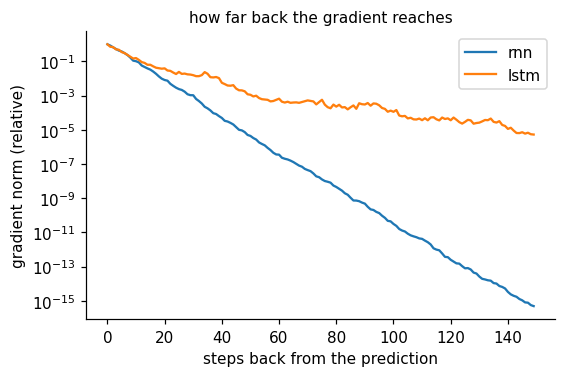

In [25]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for kind in ["rnn", "lstm"]:
    g = neural.gradient_by_distance(models[kind], train_stream).detach().numpy()
    ax.semilogy(g[:150] / g[0], label=kind)
ax.set_xlabel("steps back from the prediction"); ax.set_ylabel("gradient norm (relative)")
ax.set_title("how far back the gradient reaches", fontsize=10); ax.legend(); plt.show()

## Reading a phrase

At each step the network reads one character and outputs a distribution over the next. Here are the plain RNN's four most probable next characters along a phrase, with the probability it gave the character that actually came next (after Karpathy's "hello" example).

In [26]:
def read_phrase(model, phrase):
    ix = {c: i for i, c in enumerate(char_alpha)}
    x = torch.tensor([[ix[neural.STORY_END]] + [ix[c] for c in phrase]])
    with torch.no_grad():
        P = torch.softmax(model(x)[0][0], -1)
    for t, nxt in enumerate(phrase):
        top = torch.topk(P[t], 4)
        shown = "  ".join(f"{char_alpha[j]!r} {v:.2f}" for v, j in zip(top.values.tolist(), top.indices.tolist()))
        read = "start" if t == 0 else repr(phrase[t - 1])
        print(f"read {read:7s} next {nxt!r}: p = {P[t, ix[nxt]]:.2f}   top four: {shown}")

read_phrase(models["rnn"], "the dog barked")

read start   next 't': p = 0.17   top four: 'o' 0.60  't' 0.17  'j' 0.06  'c' 0.04
read 't'     next 'h': p = 0.28   top four: 'o' 0.34  'i' 0.30  'h' 0.28  'a' 0.06
read 'h'     next 'e': p = 0.80   top four: 'e' 0.80  'a' 0.19  'i' 0.01  'o' 0.01
read 'e'     next ' ': p = 0.66   top four: ' ' 0.66  'y' 0.24  'i' 0.08  'n' 0.01
read ' '     next 'd': p = 0.19   top four: 'd' 0.19  's' 0.12  'b' 0.11  'c' 0.08
read 'd'     next 'o': p = 0.54   top four: 'o' 0.54  'i' 0.23  'r' 0.07  'u' 0.06
read 'o'     next 'g': p = 0.38   top four: 'o' 0.42  'g' 0.38  'l' 0.06  'v' 0.04
read 'g'     next ' ': p = 0.72   top four: ' ' 0.72  '.' 0.18  ',' 0.04  '!' 0.02
read ' '     next 'b': p = 0.03   top four: 'w' 0.31  'a' 0.09  'c' 0.09  'f' 0.07
read 'b'     next 'a': p = 0.12   top four: 'e' 0.35  'o' 0.23  'u' 0.13  'a' 0.12
read 'a'     next 'r': p = 0.19   top four: 'c' 0.53  'r' 0.19  'l' 0.12  'd' 0.08
read 'r'     next 'k': p = 0.77   top four: 'k' 0.77  'n' 0.05  's' 0.03  'r' 0.03
read

## Temperature

Dividing the scores by a temperature $T$ before the softmax raises each probability to the power $1/T$: $T < 1$ sharpens, $T > 1$ flattens.

In [27]:
for T in [0.5, 1.0, 1.5]:
    print(f"T = {T}:", neural.sample_chars(models["lstm"], char_alpha, max_chars=300, temperature=T, seed=1), "\n")

T = 0.5: one day, a little girl was so happy and didn't know what to do. she was so happy to see a big box of billy's voice. "hi hould not see it both carefully me to play with you. you are sorry for you." mom said, "yes, i have to go outside and see what is in the kitchen. one day, she was angry. he said th 



T = 1.0: greezing along to searching together on the rain. she saw a smelly set off and wanted to come back but lily's mom went back to play. she picked up her, but before loved to recording body was very three years old and piptent it again. he was soon and had about. they were zoom! jake wanted to have som 



T = 1.5: greezing. he trides and drawbo. doal orry valuable heay!" ben caughing your house!" sam nodded, their noises vet, behind the wap. suddenly, but soonth, "let?" mommy reived the craps, of comings groms about ben, grash approinie ath by! one day, lily and her kite hit our fzoat! jake candy back aite ad 



## A quotation cell

Karpathy, Johnson, and Fei-Fei (2015) found LSTM cells that switch on inside quotations. Search the 256 cells of our LSTM for the one whose value best tracks being inside a quotation, over 50 held-out stories, and color an excerpt by it (red positive, blue negative).

In [28]:
from IPython.display import HTML
lstm = models["lstm"]
text = "".join(t + neural.STORY_END for t in char_test[:50])
x = neural.encode_chars(char_test[:50], char_alpha)[None]
cells = []
with torch.no_grad():
    state = None
    for t in range(x.shape[1]):                       # one step at a time, to read the cell c_t
        _, state = lstm.rnn(lstm.emb(x[:, t:t + 1]), state)
        cells.append(state[1][0, 0].clone())
cells = torch.stack(cells).numpy()
inside, flag = np.zeros(len(text)), 0
for i, ch in enumerate(text):
    flag = 0 if ch == neural.STORY_END else (1 - flag if ch == '"' else flag)
    inside[i] = flag
corr = np.array([np.corrcoef(cells[:, u], inside)[0, 1] for u in range(cells.shape[1])])
u = int(np.nanargmax(np.abs(corr)))
print(f"cell {u}: correlation {corr[u]:.2f} with being inside a quotation")
start = text.index('"', 2000) - 120
vals = cells[start:start + 400, u] / np.abs(cells[start:start + 400, u]).max()
spans = "".join(f'<span style="background: rgba({255 if v > 0 else 60},{90 if v > 0 else 110},{90 if v > 0 else 255},{abs(v):.2f})">{c}</span>'
                for c, v in zip(text[start:start + 400], vals))
HTML(f'<div style="font-family: monospace; line-height: 1.6; max-width: 46em">{spans}</div>')

cell 28: correlation 0.78 with being inside a quotation


## Watching it learn

Train a fresh, smaller LSTM for a minute and sample from it as it goes, as Karpathy's essay does: random characters, then spaces and common letters, then words.

In [29]:
torch.manual_seed(0)
student = neural.CharRNN(len(char_alpha), kind="lstm", hidden=128)
print("untrained:", neural.sample_chars(student, char_alpha, max_chars=120, seed=3))
for rounds in range(4):
    neural.train_char_rnn(student, train_stream, test_stream[:20000], steps=50, eval_every=50)
    print(f"after {50 * (rounds + 1)} steps:", neural.sample_chars(student, char_alpha, max_chars=120, seed=3), "\n")

untrained: yuj?nvfaslgt"ykzir hfd 


step    50   held-out bits per character 3.262   (3 s)
after 50 steps: yucind as btheky round top themine he too ba ont congert ta sae kwswsed shres fmat tont thiss to twhe and an tily bin py 



step    50   held-out bits per character 2.840   (3 s)
after 100 steps: yucind as bomy, ir the popetleaine he too ba ont conger a a saw kwews momer, lome witht thiss to twat a and ha laobe ouy 



step    50   held-out bits per character 2.543   (3 s)
after 150 steps: yucin has domy, in the pupttle in hh it ther one cougertery saw kwews momer, lites. the tom some twat a a bo tillose oul 



step    50   held-out bits per character 2.336   (3 s)
after 200 steps: yuch a as gore, in the pucttle in the too bay. they geat ta saw kwhes momer, lite with at it to gtwat a leak a lithe oul 



## Words instead of characters

The same LSTM over words, sized like the fixed-window model (64-dimensional word vectors, 128 units, about 1.8 million parameters), scored story by story on the same prediction events as the n-gram models. `tools/train_week02_checkpoints.py word` trains it (about 20 minutes on a laptop).

In [30]:
wl = neural.WordLSTM(len(vocab) + 1, len(vocab), embed_dim=64, hidden=128)
wl.load_state_dict(torch.load(ROOT / "checkpoints" / "week02_word_lstm.pt"))
sx, sy = neural.story_tensors(test, index)
print(f"{sum(p.numel() for p in wl.parameters()):,} parameters")
print(f"test perplexity: word LSTM {neural.story_perplexity(wl, sx, sy):.1f}, fixed window "
      f"{math.exp(neural.average_loss(lm, X_test, Y_test)):.1f}, Kneser-Ney 4-gram {results[('Kneser-Ney', 4)]:.1f}")

1,774,825 parameters


test perplexity: word LSTM 23.1, fixed window 26.9, Kneser-Ney 4-gram 24.6


## Things to try

1. **No clipping.** Train the plain RNN with `clip=1e9`. What happens to the loss early in training?
2. **Longer chunks.** Train with `length=32` and `length=256`. Truncated backpropagation through time sees at most `length` steps back; does the held-out loss change?
3. **Width.** Compare `hidden=64, 128, 256, 512` for the LSTM at a fixed number of steps. Plot held-out bits per character against the number of parameters.
4. **Temperature.** Sample from the LSTM at temperatures 0.5, 1.0, and 1.5. Which looks most like a story, and which has the lowest loss?
5. **A bigger word LSTM.** Train `WordLSTM` with 256 or 512 units with `neural.train_word_rnn`. How does its test perplexity move against its number of parameters, and against the Kneser–Ney 4-gram?
6. **Your own embeddings.** Train skip-gram with `dim=20` and `dim=300`, and with windows of 1 and 5. Which gives better neighbors? Which gives better analogies?